# veri seti bölme

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from path_setup import PROJECT_ROOT, PROCESSED_DATA_PATH, PLOTS_PATH

df = pd.read_csv(PROCESSED_DATA_PATH, index_col=0)
print(f'Veri seti şekli: {df.shape}')
print(f'Tarih aralığı: {df.index[0]} - {df.index[-1]}')

Veri seti şekli: (4217, 17)
Tarih aralığı: 2014-09-17 - 2026-04-03


In [10]:
# Hedef değişken - Close price yönü
raw_data = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'btc_usd.csv', index_col=0)

# Index'i datetime'a dönüştür
df.index = pd.to_datetime(df.index)
raw_data.index = pd.to_datetime(raw_data.index)

# Forward fill with backward fill (no deprecated method)
df_filled = df.bfill().ffill()
df_filled = df_filled.dropna()
print(f'Doldurulmuş df: {len(df_filled)} satır')

# Hedef değişken oluştur
df_filled['price_return'] = raw_data.loc[df_filled.index, 'Close'].pct_change()
df_filled['target'] = (df_filled['price_return'].shift(-1) > 0).astype(int)
df_filled = df_filled.dropna()

X = df_filled.drop(['price_return', 'target'], axis=1)
y = df_filled['target']

print(f'Özellikler: {X.shape[1]}')
print(f'Hedef dağılımı: {y.value_counts().to_dict()}')

Doldurulmuş df: 4217 satır
Özellikler: 17
Hedef dağılımı: {1: 2208, 0: 2008}


In [11]:
tscv = TimeSeriesSplit(n_splits=5)
print(f'Time Series Split: {tscv.get_n_splits()} fold')

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    train_size = len(train_idx)
    test_size = len(test_idx)
    print(f'Fold {fold}: Train={train_size}, Test={test_size} ({test_size/len(X)*100:.1f}%)')

Time Series Split: 5 fold
Fold 1: Train=706, Test=702 (16.7%)
Fold 2: Train=1408, Test=702 (16.7%)
Fold 3: Train=2110, Test=702 (16.7%)
Fold 4: Train=2812, Test=702 (16.7%)
Fold 5: Train=3514, Test=702 (16.7%)


# modelleme

In [12]:
model = Ridge(alpha=1.0)

predictions = np.zeros(len(y))
probabilities = np.zeros(len(y))
fold_scores = []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    predictions[test_idx] = (preds > 0.5).astype(int)
    probabilities[test_idx] = np.clip(preds, 0, 1)
    
    score = r2_score(y_test, preds)
    fold_scores.append(score)

print(f'Model: Ridge (alpha=1.0)')
print(f'Ortalama R² Skoru: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})')

Model: Ridge (alpha=1.0)
Ortalama R² Skoru: -0.0263 (+/- 0.0297)


In [13]:
accuracy = (predictions == y.values).sum() / len(y)
mae = mean_absolute_error(y.values, predictions)
rmse = np.sqrt(mean_squared_error(y.values, predictions))

print(f'\nSonuçlar:')
print(f'Doğruluk: {accuracy:.2%}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'\nYönü doğru tahmin: {(predictions == y.values).sum()}/{len(y)}')


Sonuçlar:
Doğruluk: 50.00%
MAE: 0.5000
RMSE: 0.7071

Yönü doğru tahmin: 2108/4216


# 1. grafik

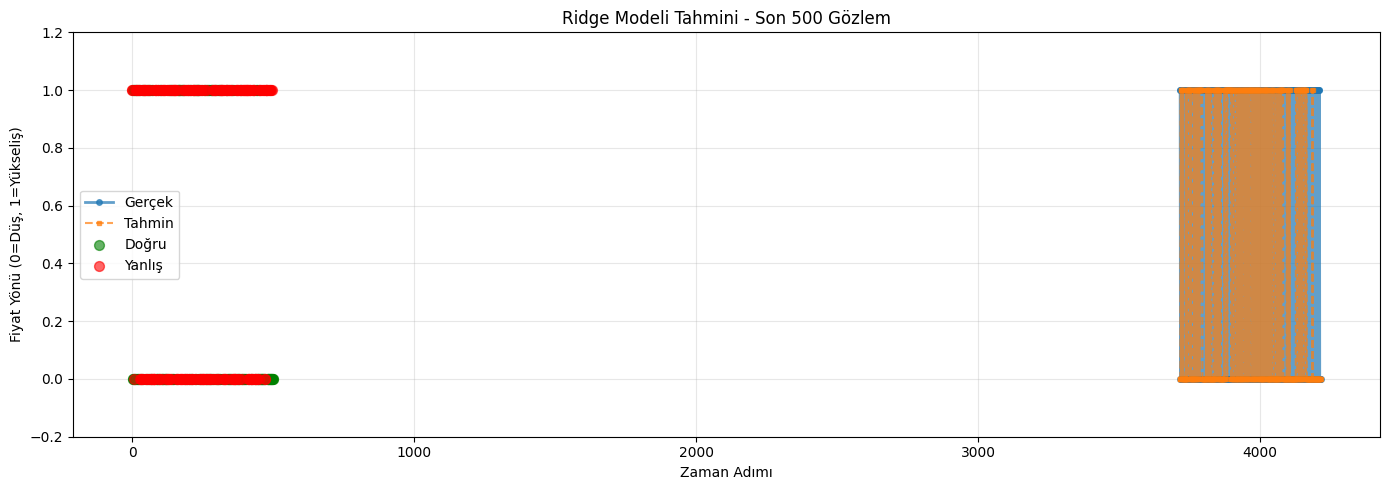

Grafik kaydedildi: model_predictions.png


In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

window = 500
ax.plot(range(len(y))[-window:], y.values[-window:], 'o-', label='Gerçek', alpha=0.7, linewidth=2, markersize=4)
ax.plot(range(len(y))[-window:], predictions[-window:], 's--', label='Tahmin', alpha=0.7, linewidth=1.5, markersize=3)

correct = predictions[-window:] == y.values[-window:]
ax.scatter(np.where(correct)[-window:], y.values[-window:][correct], color='green', s=50, alpha=0.6, label='Doğru', zorder=5)
ax.scatter(np.where(~correct)[-window:], y.values[-window:][~correct], color='red', s=50, alpha=0.6, label='Yanlış', zorder=5)

ax.set_xlabel('Zaman Adımı')
ax.set_ylabel('Fiyat Yönü (0=Düş, 1=Yükseliş)')
ax.set_title(f'Ridge Modeli Tahmini - Son 500 Gözlem')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.2, 1.2)

plt.tight_layout()
plt.savefig(PLOTS_PATH / 'model_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

print('Grafik kaydedildi: model_predictions.png')

# 2. grafik

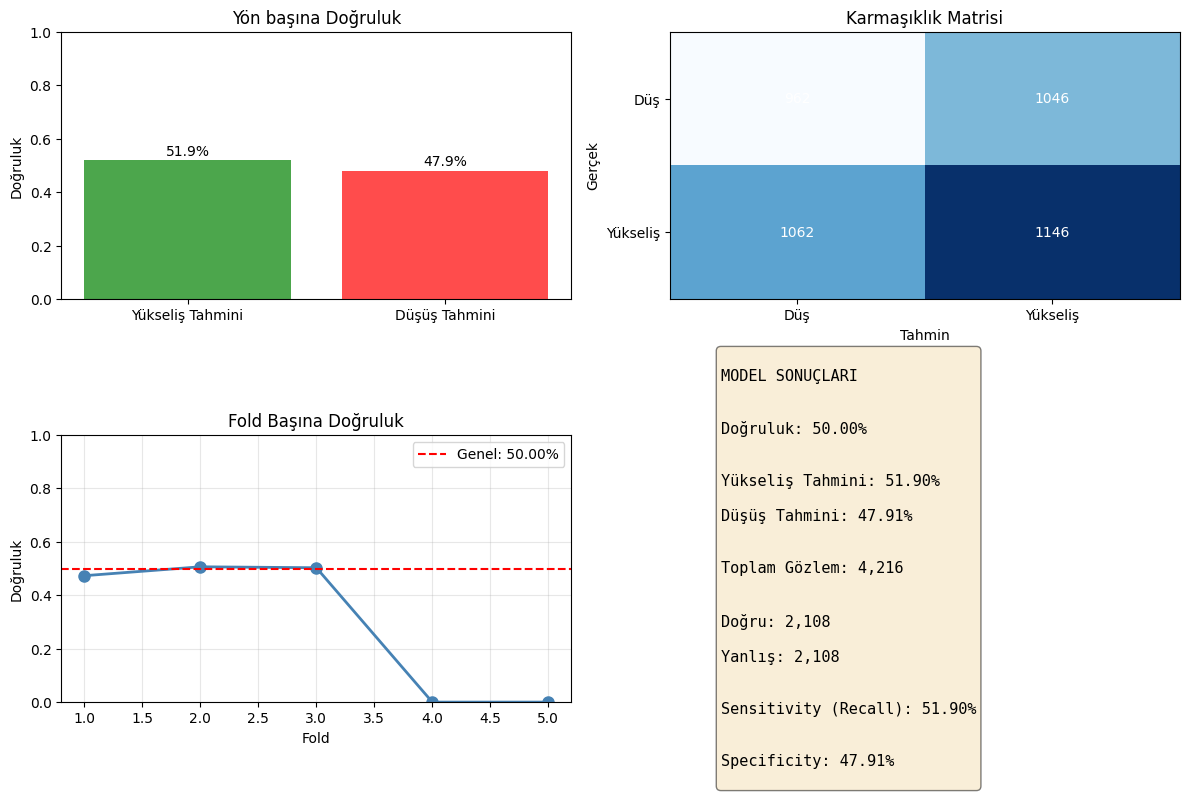

Grafik kaydedildi: model_analysis.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Şartlı doğruluk
up_acc = (predictions[y == 1] == y[y == 1]).sum() / (y == 1).sum()
down_acc = (predictions[y == 0] == y[y == 0]).sum() / (y == 0).sum()

axes[0, 0].bar(['Yükseliş Tahmini', 'Düşüş Tahmini'], [up_acc, down_acc], color=['green', 'red'], alpha=0.7)
axes[0, 0].set_ylabel('Doğruluk')
axes[0, 0].set_title('Yön başına Doğruluk')
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate([up_acc, down_acc]):
    axes[0, 0].text(i, v + 0.02, f'{v:.1%}', ha='center')

# Karmaşıklık Matrisi
tp = ((predictions == 1) & (y == 1)).sum()
fp = ((predictions == 1) & (y == 0)).sum()
tn = ((predictions == 0) & (y == 0)).sum()
fn = ((predictions == 0) & (y == 1)).sum()

cm = np.array([[tn, fp], [fn, tp]])
im = axes[0, 1].imshow(cm, cmap='Blues', aspect='auto')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_yticks([0, 1])
axes[0, 1].set_xticklabels(['Düş', 'Yükseliş'])
axes[0, 1].set_yticklabels(['Düş', 'Yükseliş'])
axes[0, 1].set_ylabel('Gerçek')
axes[0, 1].set_xlabel('Tahmin')
axes[0, 1].set_title('Karmaşıklık Matrisi')
for i in range(2):
    for j in range(2):
        axes[0, 1].text(j, i, f'{cm[i, j]}', ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')

# Kümülatif Doğruluk
fold_idx = np.array([len(x) for x, _ in tscv.split(X)])
fold_cumsum = np.cumsum(fold_idx)
fold_accs = []
prev = 0
for start, end in zip([0] + list(fold_cumsum[:-1]), fold_cumsum):
    subset_acc = (predictions[start:end] == y.values[start:end]).sum() / (end - start)
    fold_accs.append(subset_acc)

axes[1, 0].plot(range(1, len(fold_accs) + 1), fold_accs, 'o-', linewidth=2, markersize=8, color='steelblue')
axes[1, 0].axhline(accuracy, color='red', linestyle='--', label=f'Genel: {accuracy:.2%}')
axes[1, 0].set_xlabel('Fold')
axes[1, 0].set_ylabel('Doğruluk')
axes[1, 0].set_title('Fold Başına Doğruluk')
axes[1, 0].legend()
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(True, alpha=0.3)

# Özeti
axes[1, 1].axis('off')
summary_text = f'''\nMODEL SONUÇLARI\n\n
Doğruluk: {accuracy:.2%}\n\n
Yükseliş Tahmini: {up_acc:.2%}\n
Düşüş Tahmini: {down_acc:.2%}\n\n
Toplam Gözlem: {len(y):,}\n\n
Doğru: {(predictions == y.values).sum():,}\n
Yanlış: {(predictions != y.values).sum():,}\n\n
Sensitivity (Recall): {tp/(tp+fn):.2%}\n\n
Specificity: {tn/(tn+fp):.2%}
'''

axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, family='monospace', 
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(PLOTS_PATH / 'model_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print('Grafik kaydedildi: model_analysis.png')